In [6]:
from pathlib import Path
print("Working directory:", Path.cwd())
print("\nContents:")
for p in sorted(Path.cwd().iterdir()):
    print("  ", p.name)


Working directory: C:\Users\amirtha\projects\home-credit-risk-platform

Contents:
   .env
   .env.example
   .git
   .github
   .gitignore
   .ipynb_checkpoints
   .venv
   01_eda.ipynb
   app
   data
   infra
   knowledge_base
   notebooks
   README.md
   requirements.txt
   src
   tests


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 100)
RAW = Path("data/raw")

files = sorted(RAW.glob("*.csv"))
for f in files:
    size_mb = f.stat().st_size / 1_048_576
    print(f"{f.name:35s} {size_mb:8.1f} MB")


application_test.csv                    25.3 MB
application_train.csv                  158.4 MB
bureau.csv                             162.1 MB
bureau_balance.csv                     358.2 MB
credit_card_balance.csv                404.9 MB
HomeCredit_columns_description.csv       0.0 MB
installments_payments.csv              689.6 MB
POS_CASH_balance.csv                   374.5 MB
previous_application.csv               386.2 MB
sample_submission.csv                    0.5 MB


In [5]:
app = pd.read_csv(RAW / "application_train.csv")
print(f"Shape: {app.shape}")
app.head()

Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single /

TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%


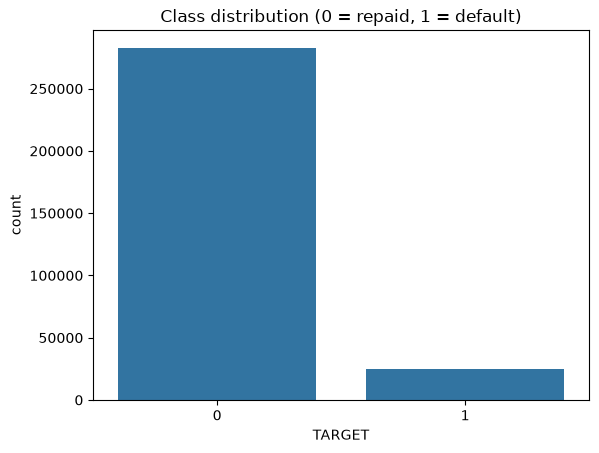

In [7]:
target_counts = app["TARGET"].value_counts()
target_pct = app["TARGET"].value_counts(normalize=True) * 100

print(target_counts)
print(f"\nDefault rate: {target_pct[1]:.2f}%")

sns.countplot(data=app, x="TARGET")
plt.title("Class distribution (0 = repaid, 1 = default)")
plt.show()

In [8]:
missing = app.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(app) * 100).round(1)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
missing_df[missing_df["missing"] > 0].head(30)

,missing,pct
COMMONAREA_AVG,214865,69.9
COMMONAREA_MODE,214865,69.9
COMMONAREA_MEDI,214865,69.9
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4


In [9]:
for name in ["bureau", "previous_application", "installments_payments",
             "POS_CASH_balance", "credit_card_balance"]:
    df = pd.read_csv(RAW / f"{name}.csv", nrows=5)
    full = pd.read_csv(RAW / f"{name}.csv", usecols=[0])
    print(f"{name:25s} rows: {len(full):>10,}  cols: {df.shape[1]}")
    print(f"  keys: {[c for c in df.columns if c.startswith('SK_ID')]}\n")

bureau                    rows:  1,716,428  cols: 17
  keys: ['SK_ID_CURR', 'SK_ID_BUREAU']

previous_application      rows:  1,670,214  cols: 37
  keys: ['SK_ID_PREV', 'SK_ID_CURR']

installments_payments     rows: 13,605,401  cols: 8
  keys: ['SK_ID_PREV', 'SK_ID_CURR']

POS_CASH_balance          rows: 10,001,358  cols: 8
  keys: ['SK_ID_PREV', 'SK_ID_CURR']

credit_card_balance       rows:  3,840,312  cols: 23
  keys: ['SK_ID_PREV', 'SK_ID_CURR']



EXT_SOURCE_1: corr with TARGET = -0.1553
EXT_SOURCE_2: corr with TARGET = -0.1605
EXT_SOURCE_3: corr with TARGET = -0.1789


C:\Users\amirtha\AppData\Local\Temp\ipykernel_28444\1358492607.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app["AGE_YEARS"] = (-app["DAYS_BIRTH"] / 365).round(0)


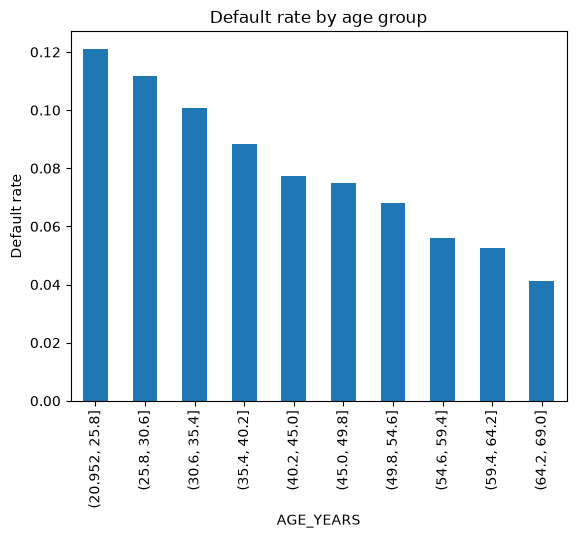

In [10]:
# External credit scores — typically the strongest predictors
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
for col in ext_cols:
    print(f"{col}: corr with TARGET = {app[col].corr(app['TARGET']):.4f}")

# Age effect
app["AGE_YEARS"] = (-app["DAYS_BIRTH"] / 365).round(0)
age_default = app.groupby(pd.cut(app["AGE_YEARS"], bins=10))["TARGET"].mean()
age_default.plot(kind="bar", title="Default rate by age group")
plt.ylabel("Default rate")
plt.show()

In [11]:
print(app["DAYS_EMPLOYED"].describe())
print(f"\nAnomalous value count: {(app['DAYS_EMPLOYED'] == 365243).sum():,}")

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

Anomalous value count: 55,374


## Preliminary Findings
1. The data contains more than 300K loan applications.
2. There is a lot of missing data in many of the columns which have to be addressed.
3. Approximately 8% of defaults in the data.
4. Many historical records of applicants need to be aggregated to get one prediction per applicant.
5. Found a value of 365243 in number of days employed (translating to 1000 years of employment) - which is probably a sentinel value. 